In [1]:
import torch, torch.nn as nn
import snntorch as snn
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

In [2]:
from torchvision.datasets import MNIST
from torchvision.transforms import Compose, Grayscale, ToTensor, Normalize, Lambda
from torch.utils.data import DataLoader

transform = Compose([
    Grayscale(),
    ToTensor(),
    Normalize((0,), (1,)),
    Lambda(lambda x: torch.flatten(x))
])

mnist_train = MNIST('./data/', train=True, download=True, transform=transform)
train_loader = DataLoader(mnist_train, batch_size=128, shuffle=True)

mnist_test = MNIST('./data/', train=False, download=True, transform=transform)
test_loader = DataLoader(mnist_train, batch_size=128, shuffle=False)

100%|██████████| 9.91M/9.91M [00:05<00:00, 1.65MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 136kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 1.90MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.94MB/s]


In [4]:
from tqdm import tqdm
from torch.optim import Adam
import torch.nn.functional as F

class LeakyLayer(nn.Linear):

    def __init__(self, in_features, out_features, activation, bias=False):
        super().__init__(in_features, out_features, bias=bias)

        # Enable the choice between a spiking neuron and a standard artificial neuron (ReLU activation)
        if activation == "lif":
            self.activation = snn.Leaky(beta=0.8)
            self.lif = True
        else:
            self.activation = nn.ReLU()
            self.lif = False

        self.opt = Adam(self.parameters(), lr=0.03)
        self.threshold = 5.0
        self.num_epochs = 1000

    def forward(self, x):
        if self.lif == True:
            mem = self.activation.init_leaky() # initialize membrane potential

        x_direction = x / (torch.norm(x, p=2, dim=1, keepdim=True) + 1e-4) # normalize the input

        # Linear layer - not using nn.Linear(...) so we can define the update rule
        weighted_input = torch.mm(x_direction, self.weight.T.to(device)) # MatMul between normalized input and weight matrix

        if self.lif == True:
            spk, potential = self.activation(weighted_input, mem) # note: only one step in time. Wrap in a for-loop to iterate for longer.
        else:
            potential = self.activation(weighted_input)

        return potential  # to be used in subsequent layers or as the final output of the last layer

    def train(self, x_pos, x_neg):

        tot_loss = []  # store the loss values for each layer in each epoch
        for _ in tqdm(range(self.num_epochs), desc="Training LeakyLayer"):

            # Compute goodness
            g_pos = self.forward(x_pos).pow(2).mean(1) # positive data
            g_neg = self.forward(x_neg).pow(2).mean(1) # negative data

            # take the mean of differences between goodness and threshold across pos and neg samples
            loss = F.softplus(torch.cat([-g_pos + self.threshold, g_neg - self.threshold])).mean()

            self.opt.zero_grad()
            loss.backward() # local backward-pass
            self.opt.step() # update weights
            tot_loss.append(loss)

        # returns the final membrane potentials (activations) for positive and negative examples after training.
        # detach() ensures no further backward pass is possible
        output = self.forward(x_pos).detach(), self.forward(x_neg).detach()
        return (output, tot_loss)

In [5]:
class Net(nn.Module):

    def __init__(self, dims, activation):
        super().__init__()

        self.layers = nn.ModuleList([
            LeakyLayer(dims[d], dims[d + 1], activation) for d in range(len(dims) - 1)  # define a multi-layer network
        ])


    def predict(self, x):
        goodness_per_label = [] # used to store the goodness values for each label

        for label in range(10): # loop over the 10 possible labels
            h = overlay_y_on_x(x, label)  # overlay label information on top of the input data. function defined in next code-block.
            goodness = []

            for layer in self.layers: # inner loop over the layers
                h = layer(h)
                goodness.append(h.pow(2).mean(1)) # compute and store goodness for every layer

            goodness_per_label.append(sum(goodness).unsqueeze(1)) # sum goodness values between all layers for one sample of data

        goodness_per_label = torch.cat(goodness_per_label, 1)  # convert list to tensor

        return goodness_per_label.argmax(1)  # returns maximum value giving the predicted label for each input

    def train(self, x_pos, x_neg):
        h_pos, h_neg = x_pos, x_neg
        layer_losses = []
        for i, layer in enumerate(self.layers):
            print('Training layer', i, '...')
            outputs, loss = layer.train(h_pos, h_neg)  # update the weight matrix for each layer based on the local loss (defined by "goodness")
            h_pos, h_neg = outputs
            layer_losses.append(loss)
        return torch.Tensor(layer_losses)

In [6]:
import matplotlib.pyplot as plt

def overlay_y_on_x(x, y):
    """Replace the first 10 pixels of data [x] with one-hot-encoded label [y]"""
    x_ = x.clone()
    x_[:, :10] *= 0.0  # zero out the first 10 pixels of input data
    x_[range(x.shape[0]), y] = x.max()  # the y-label 'activates' the corresponding pixel
    return x_

def visualize_sample(data, name='', idx=0):
    reshaped = data[idx].cpu().reshape(28, 28)
    plt.figure(figsize = (4, 4))
    plt.title(name)
    plt.imshow(reshaped, cmap="gray")
    plt.show()

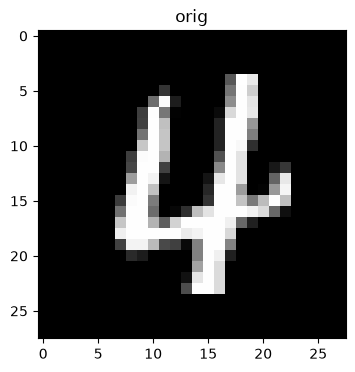

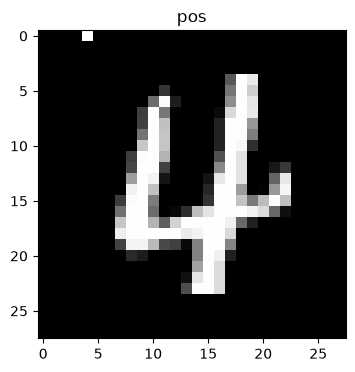

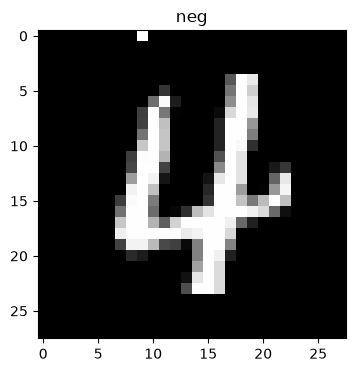

In [7]:
torch.manual_seed(123)
net = Net([784, 500, 500], "lif").to(device) # construct neural net with 784 input neurons, 500 neurons in each of the two hidden layers
x, y = next(iter(train_loader))
x, y = x.to(device), y.to(device)

x_pos = overlay_y_on_x(x, y)  # generate positive samples (i.e., correct labels overlayed on input data)

# generate negative samples (i.e., incorrect labels overlayed on input data)
rnd = torch.randperm(x.size(0))
x_neg = overlay_y_on_x(x, y[rnd])  #

# visualize samples
for data, name in zip([x, x_pos, x_neg], ['orig', 'pos', 'neg']):
    visualize_sample(data, name)

In [8]:
net.train(x_pos, x_neg)
print('Train error:', 100*(1.0 - net.predict(x).eq(y).float().mean().item()),'%')

Training layer 0 ...


Training LeakyLayer: 100%|██████████| 1000/1000 [00:07<00:00, 140.29it/s]


Training layer 1 ...


Training LeakyLayer: 100%|██████████| 1000/1000 [00:05<00:00, 167.31it/s]
C:\Users\emiel\AppData\Local\Temp\ipykernel_28128\4140782493.py:36: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:821.)
  return torch.Tensor(layer_losses)


Train error: 42.1875 %


In [9]:
x_te, y_te = next(iter(test_loader))
x_te, y_te = x_te.to(device), y_te.to(device)

print('Test error:', 100*(1.0 - net.predict(x_te).eq(y_te).float().mean().item()), '%')

Test error: 70.3125 %


In [10]:
plt.plot(layer_losses[0,:], label="Layer 1 Loss")
plt.plot(layer_losses[1,:], label="Layer 2 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

NameError: name 'layer_losses' is not defined

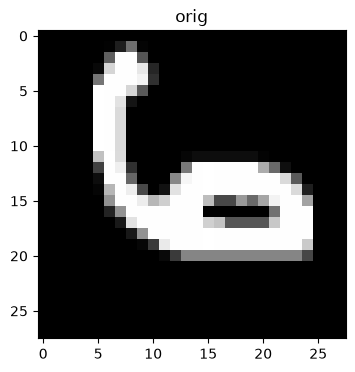

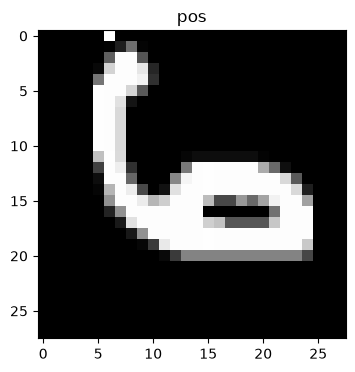

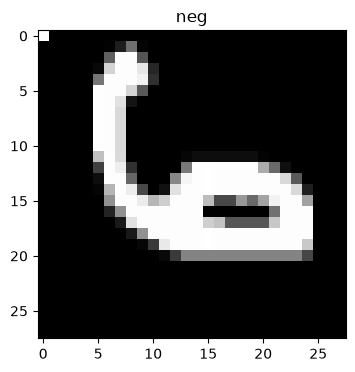

Training layer 0 ...


Training LeakyLayer:  60%|█████▉    | 598/1000 [00:03<00:02, 173.77it/s]

In [ ]:
net = Net([784, 500, 500], "relu").to(device)

# load training data
x, y = next(iter(train_loader))
x, y = x.to(device), y.to(device)

# overlay labels on data
x_pos = overlay_y_on_x(x, y)
rnd = torch.randperm(x.size(0))
x_neg = overlay_y_on_x(x, y[rnd])

# visaualize samples
for data, name in zip([x, x_pos, x_neg], ['orig', 'pos', 'neg']):
    visualize_sample(data, name)

net.train(x_pos, x_neg)
print('train error:', 100*(1.0 - net.predict(x).eq(y).float().mean().item()),'%')

# load test data
x_te, y_te = next(iter(test_loader))
x_te, y_te = x_te.to(device), y_te.to(device)
print('test error:', 100*(1.0 - net.predict(x_te).eq(y_te).float().mean().item()),'%')